# Tutorial: Teaching Machines to Read — Sentiment Analysis with TF-IDF

**Objective:** In this tutorial, we explore Natural Language Processing (NLP). Our goal is to take 5,000 unstructured movie reviews and teach a computer to mathematically distinguish between a "Positive" and a "Negative" sentiment.

**The Strategy:**
Cleaning: Removing HTML tags and punctuation from the text.

**Vectorization:** Using TF-IDF to turn words into unique mathematical scores.

**Classification:** Training a Linear Support Vector Machine (LinearSVC) to find the boundary between sentiments.
Interpretation: Visualizing the specific words that the model "learned" are positive or negative.

In [1]:
# First, we import our tools for data, text, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# This line lets us see our plots right inside the notebook
%matplotlib inline

# We'll make an output folder for our results
if not os.path.exists('output'):
    os.makedirs('output')

# Downloading the common English "stop words" (like 'the', 'is', 'at')
print("Downloading NLP components...")
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print("All libraries and NLP tools are ready!")

All libraries and NLP tools are ready!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Step 1: Loading the Text Data

We are using the IMDB Dataset. To keep the tutorial fast and efficient for the user, we will take a sample of 5,000 reviews.


In [7]:
# Loading the dataset from our 'data' folder
# Note: You can find this dataset on Kaggle (IMDB Dataset.csv)
df = pd.read_csv('data/IMDB_Dataset.csv').sample(5000, random_state=42)

# Let's see what a raw review looks like
print("Sample Review:")
print(df['review'].iloc[0][:200] + "...")

Sample Review:
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev...


## Step 2: Intermediate Cleaning (Text Normalization)

Computers are confused by HTML tags like <br /> and punctuation. We'll write a simple function to clean the text and remove "noise."

In [8]:
# A simple function to clean our text
def clean_text(text):
    text = text.lower() # Everything to lowercase
    text = re.sub(r'<br />', ' ', text) # Remove HTML break tags
    text = re.sub(r'[^a-z ]', '', text) # Remove anything that isn't a letter
    return text

print("Cleaning 5,000 reviews... please wait.")
df['review'] = df['review'].apply(clean_text)

print("Text cleaning is finished!")

Cleaning 5,000 reviews... please wait.
Text cleaning is finished!


## Step 3: Splitting the Data

We split our cleaned reviews into a Training set (80%) and a Test set (20%).

In [9]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} reviews. Testing on {len(X_test)} reviews.")

Training on 4000 reviews. Testing on 1000 reviews.


## Step 4: The Math of Meaning (TF-IDF)

This is the most important part of the tutorial. We use TF-IDF (Term Frequency-Inverse Document Frequency) to turn words into numbers.
TF: Counts how often a word appears.
IDF: Penalizes words that appear everywhere (like "the") because they don't help us find the sentiment.

In [10]:
# Turning words into a mathematical matrix
# We limit to the top 2,500 most important words
vectorizer = TfidfVectorizer(max_features=2500, stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Words have been successfully turned into numbers!")

Words have been successfully turned into numbers!


## Step 5: Training the Sentiment Classifier

We use a Linear Support Vector Machine. In high-dimensional text space, a simple linear boundary is often the most accurate and fastest way to separate positive and negative reviews.

In [11]:
# Training our model
model = LinearSVC(C=1.0, random_state=42)
model.fit(X_train_tfidf, y_train)

# Checking the accuracy
y_pred = model.predict(X_test_tfidf)
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")

Final Model Accuracy: 83.50%


## Step 6: Visualizing the "Words that Matter"

This is our "Creative Teaching Tool." We extract the weights from the model to see exactly which words are pushing the prediction toward "Positive" (Green) or "Negative" (Red).

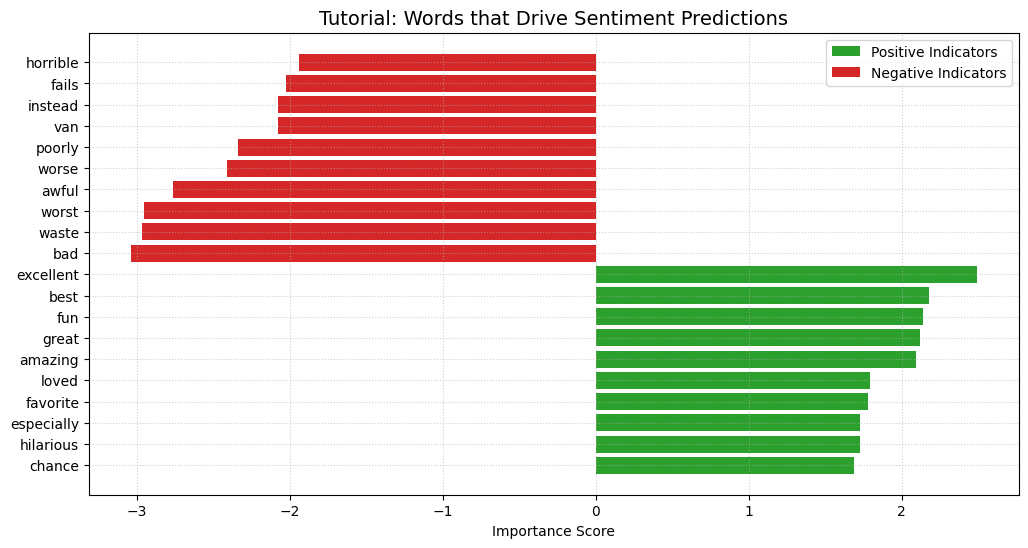

In [12]:
# Getting the most influential words
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_.flatten()

# Sorting the top 10 positive and 10 negative words
top_pos = np.argsort(coefficients)[-10:]
top_neg = np.argsort(coefficients)[:10]

# Plotting
plt.figure(figsize=(12, 6))
plt.barh(feature_names[top_pos], coefficients[top_pos], color='#2ca02c', label='Positive Indicators')
plt.barh(feature_names[top_neg], coefficients[top_neg], color='#d62728', label='Negative Indicators')
plt.title("Tutorial: Words that Drive Sentiment Predictions", fontsize=14)
plt.xlabel("Importance Score")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Save to our folder
plt.savefig('output/word_importance.png', dpi=300)
plt.show()

## Step 7: Confusion Matrix

To finish, we use a Confusion Matrix to see where the model made mistakes. This is a standard professional tool for error analysis.

<Figure size 640x480 with 0 Axes>

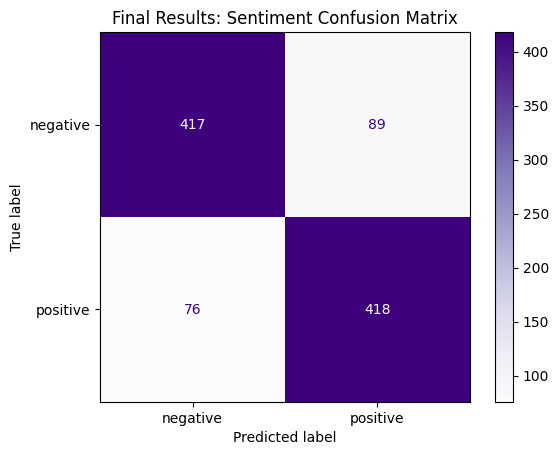

In [13]:
# Final evaluation plot
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Purples')
plt.title("Final Results: Sentiment Confusion Matrix")

plt.savefig('output/confusion_matrix.png', dpi=300)
plt.show()